# Parallelism Mix Strategy — Composing DP, TP, PP, SP, CP & EP

> **Difficulty:** Intermediate → Advanced | **Time:** ~60 min | **Prerequisites:** Notebooks 01–06

Real-world large model training never uses a single parallelism strategy in isolation.
GPT-3 175B, LLaMA 70B, and Mixtral 8×22B all combine **multiple parallelism dimensions**
simultaneously — a technique known as **3D, 4D, or 5D parallelism**.

This notebook teaches you:
1. Which parallelism dimensions **compose** (orthogonal) vs. which share resources
2. How to **map parallelism groups onto physical GPU topology** (nodes, NVLink domains)
3. The **memory and communication trade-offs** of each configuration
4. A practical **decision framework** for choosing the right mix
5. **Megatron-LM flags** that wire it all together

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import sys, os

# Ensure mp_tutorial is importable
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
from mp_tutorial.viz import (
    draw_gpu_topology_grid,
    draw_parallelism_mix_comparison,
    draw_memory_comm_tradeoff,
    draw_decision_flowchart,
    draw_process_group_boxes,
    draw_memory_breakdown_chart,
    GPU_COLORS,
)

## 1. Concepts & Principles

### Recap — The Six Parallelism Dimensions

| Abbr | Strategy | What is split | Notebook |
|------|----------|---------------|----------|
| **DP** | Data Parallelism | Training data (batches) | 01 |
| **TP** | Tensor Parallelism | Weight matrices (columns/rows) | 02 |
| **PP** | Pipeline Parallelism | Model layers (stages) | 03 |
| **SP** | Sequence Parallelism | Activations along the sequence dimension | 04 |
| **CP** | Context Parallelism | Long-sequence attention (ring attention) | 05 |
| **EP** | Expert Parallelism | MoE expert replicas | 06 |

Each dimension partitions a different axis of the computation. The key insight is that
**most of these dimensions are orthogonal** — they can be freely combined because they
split different things.

### Composability Rules

Not all combinations are independent. Here are the rules:

| Rule | Explanation |
|------|-------------|
| **TP ⊥ PP ⊥ DP** | Tensor, pipeline, and data parallelism are fully orthogonal. Total GPUs = DP × TP × PP |
| **SP shares TP's group** | Sequence parallelism uses the same process group as TP — it partitions the activations that TP already split. No extra GPUs needed |
| **CP is orthogonal** | Context parallelism adds a separate dimension for long-sequence attention. It can be combined with TP+PP+DP |
| **EP adds a dimension** | Expert parallelism overlays on top of DP — a subset of DP replicas instead hold different experts |

#### The GPU Count Formula

$$\text{Total GPUs} = DP \times TP \times PP$$

With SP: no additional GPUs (SP reuses TP's group).

With CP: $\text{Total GPUs} = DP \times TP \times PP \times CP$

With EP: EP subdivides the DP dimension, so $DP = DP_{\text{pure}} \times EP$.

### 3D, 4D, and 5D Parallelism

These names describe how many **independent** parallelism dimensions are active:

| Name | Dimensions | Typical Use Case |
|------|-----------|------------------|
| **3D Parallelism** | DP × TP × PP | Standard for 10B–200B models on multi-node clusters |
| **4D Parallelism** | DP × TP × PP × SP (or CP) | Adds activation memory savings (SP) or supports very long sequences (CP) |
| **5D Parallelism** | DP × TP × PP × SP × EP | Mixture-of-Experts models like Mixtral, distributing experts across GPUs |

> **Key idea:** Start simple (DP only), add dimensions **only when you run out of memory
> or need to scale further**. Each added dimension brings communication overhead.

### Process Group Hierarchy

In frameworks like Megatron-LM, parallelism groups are organized hierarchically.
Think of it as nested loops:

```
for dp_rank in range(DP):          # outermost — spans across nodes
    for pp_rank in range(PP):       # middle — spans across nodes
        for tp_rank in range(TP):   # innermost — within one node (fast NVLink)
            gpu_id = dp_rank * PP * TP + pp_rank * TP + tp_rank
```

**Why this order?** TP requires the highest communication bandwidth
(allreduce every forward/backward step), so it should use the fastest interconnect
(NVLink within a node). PP only sends activations between adjacent stages.
DP syncs gradients once per step, so it tolerates slower cross-node links.

In [2]:
# Demonstrate process group assignment
def assign_gpu_ranks(dp_size, pp_size, tp_size):
    """Show how each GPU gets assigned (TP rank, PP rank, DP rank)."""
    total = dp_size * pp_size * tp_size
    print(f"Total GPUs: {total}  (DP={dp_size} × PP={pp_size} × TP={tp_size})")
    print(f"{'GPU':>5} {'TP rank':>8} {'PP rank':>8} {'DP rank':>8}")
    print("-" * 35)
    for d in range(dp_size):
        for p in range(pp_size):
            for t in range(tp_size):
                gpu = d * pp_size * tp_size + p * tp_size + t
                print(f"{gpu:>5} {t:>8} {p:>8} {d:>8}")

assign_gpu_ranks(dp_size=2, pp_size=2, tp_size=2)

Total GPUs: 8  (DP=2 × PP=2 × TP=2)
  GPU  TP rank  PP rank  DP rank
-----------------------------------
    0        0        0        0
    1        1        0        0
    2        0        1        0
    3        1        1        0
    4        0        0        1
    5        1        0        1
    6        0        1        1
    7        1        1        1


Now let's **see** the same hierarchy as nested boxes — each GPU lives inside a TP group,
inside a PP stage, inside a DP replica:

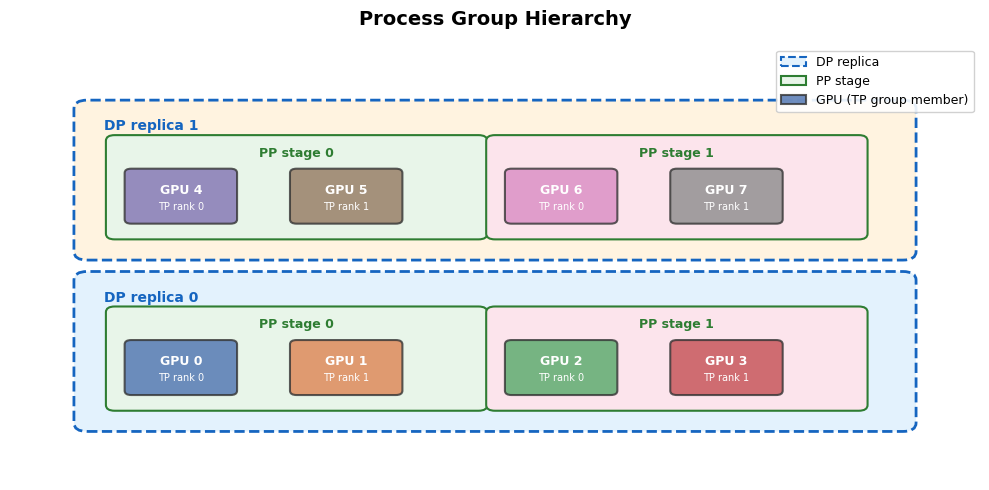

In [3]:
# Visualize the process group hierarchy as nested boxes
fig, ax = draw_process_group_boxes(dp_size=2, pp_size=2, tp_size=2)
plt.show()

## 2. Visual Illustrations

### GPU Topology Mapping

The most important visualization for mixed parallelism is seeing **how process groups
map onto physical hardware**. Below we show a 2-node, 4-GPU-per-node cluster with
3D parallelism (TP=2, PP=2, DP=2).

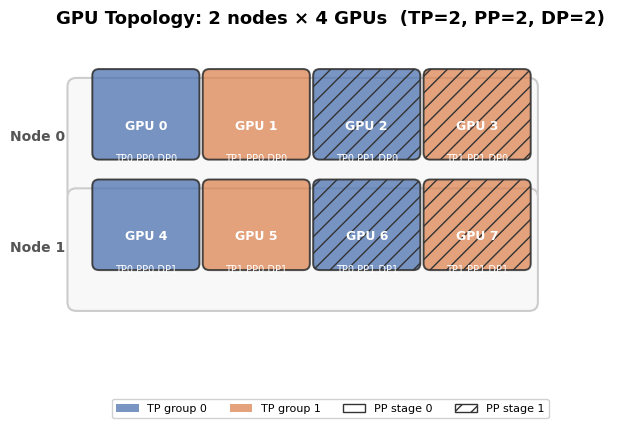

In [4]:
# 3D parallelism on 2 nodes × 4 GPUs
fig, ax = draw_gpu_topology_grid(
    num_nodes=2, gpus_per_node=4,
    tp_size=2, pp_size=2, dp_size=2
)
plt.show()

**Reading the diagram:**
- **Colors** → TP groups (GPUs that split weight matrices together, need NVLink)
- **Hatching** → PP stages (GPUs that hold different layers of the model)
- **Same TP+PP pattern across different GPUs** → DP replicas (same model, different data)

Notice that TP groups are **within the same node** (fast interconnect), while PP and DP
span across nodes.

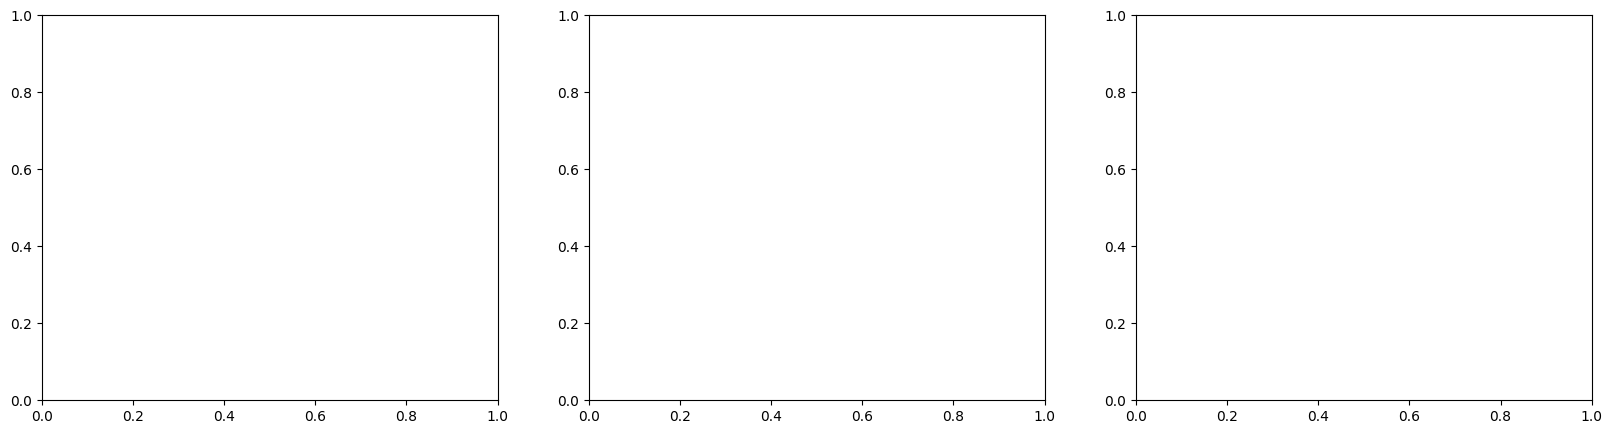

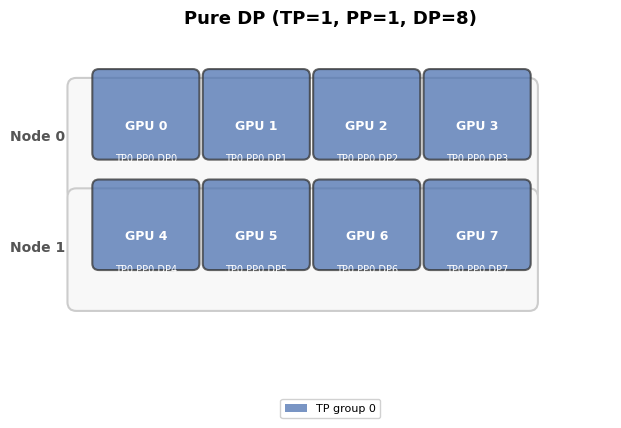

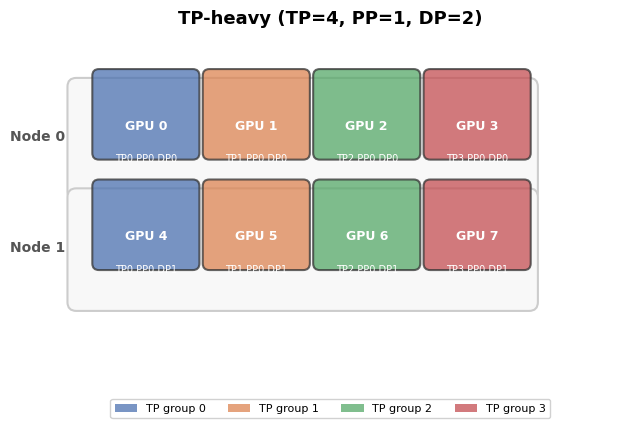

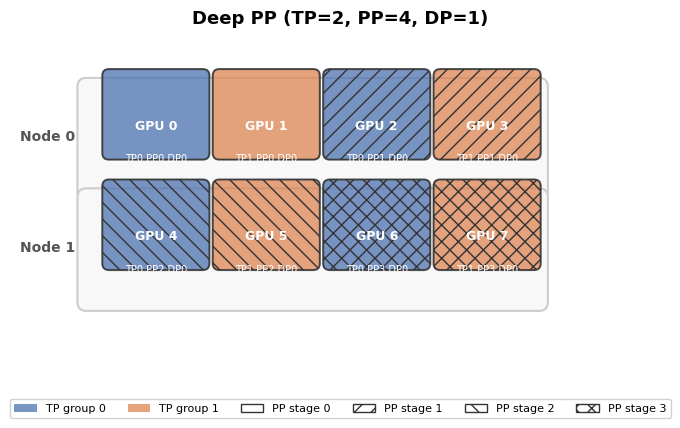

In [5]:
# Let's try different configurations on the same 8-GPU cluster
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

configs = [
    {"tp": 1, "pp": 1, "dp": 8, "label": "Pure DP (TP=1, PP=1, DP=8)"},
    {"tp": 4, "pp": 1, "dp": 2, "label": "TP-heavy (TP=4, PP=1, DP=2)"},
    {"tp": 2, "pp": 4, "dp": 1, "label": "Deep PP (TP=2, PP=4, DP=1)"},
]

for i, cfg in enumerate(configs):
    fig_i, ax_i = draw_gpu_topology_grid(
        num_nodes=2, gpus_per_node=4,
        tp_size=cfg["tp"], pp_size=cfg["pp"], dp_size=cfg["dp"],
        title=cfg["label"]
    )
    plt.show()

## 3. Memory & Communication Analysis

### Memory Per GPU

The total memory per GPU for mixed-precision training (fp16 forward, fp32 optimizer):

$$M_{\text{GPU}} = \underbrace{\frac{2P}{TP \cdot PP}}_{\text{fp16 params}} + \underbrace{\frac{12P}{TP \cdot PP}}_{\text{optimizer states}} + \underbrace{A(B, S, H, TP, PP)}_{\text{activations}}$$

Where:
- $P$ = total model parameters
- $2P / (TP \cdot PP)$ = fp16 model weights per GPU (2 bytes each)
- $12P / (TP \cdot PP)$ = Adam optimizer states (fp32 copy + momentum + variance = 4+4+4 bytes)
- $A$ = activation memory (depends on batch size $B$, sequence length $S$, hidden size $H$)

### Communication Per Step

| Dimension | Operation | Volume per step | When |
|-----------|-----------|-----------------|------|
| **TP** | AllReduce | $2 \times H \times B \times S$ per layer (fwd+bwd) | Every layer, fwd & bwd |
| **PP** | Point-to-point | $B \times S \times H$ (activation tensor) | Between adjacent stages |
| **DP** | AllReduce | $2P / TP$ (gradients) | Once per step |
| **SP** | AllGather + ReduceScatter | $B \times S \times H$ | Around LayerNorm/Dropout |

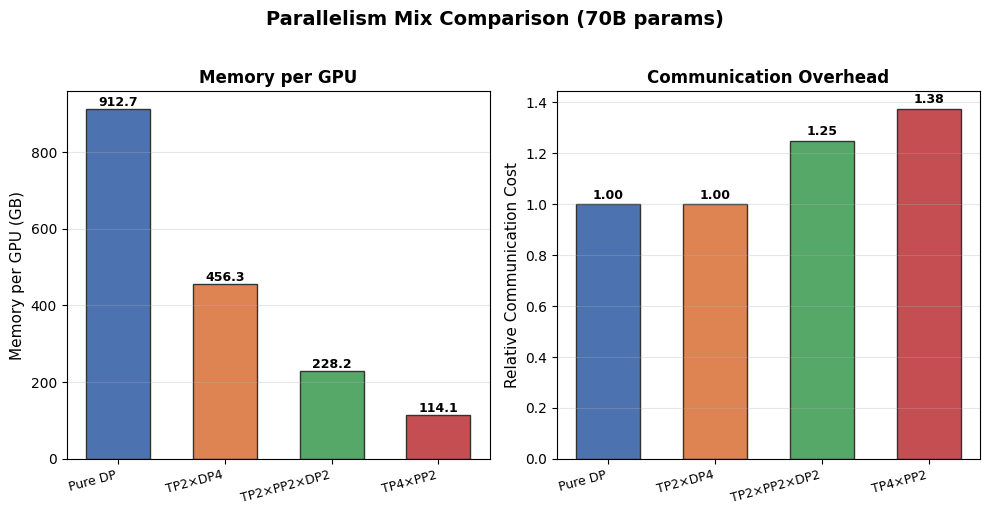

In [6]:
# Compare memory and communication for different mixes on a 70B model
configs = [
    {"tp": 1, "pp": 1, "dp": 8, "label": "Pure DP"},
    {"tp": 2, "pp": 1, "dp": 4, "label": "TP2×DP4"},
    {"tp": 2, "pp": 2, "dp": 2, "label": "TP2×PP2×DP2"},
    {"tp": 4, "pp": 2, "dp": 1, "label": "TP4×PP2"},
]

fig, axes = draw_parallelism_mix_comparison(configs, model_params=70e9)
plt.show()

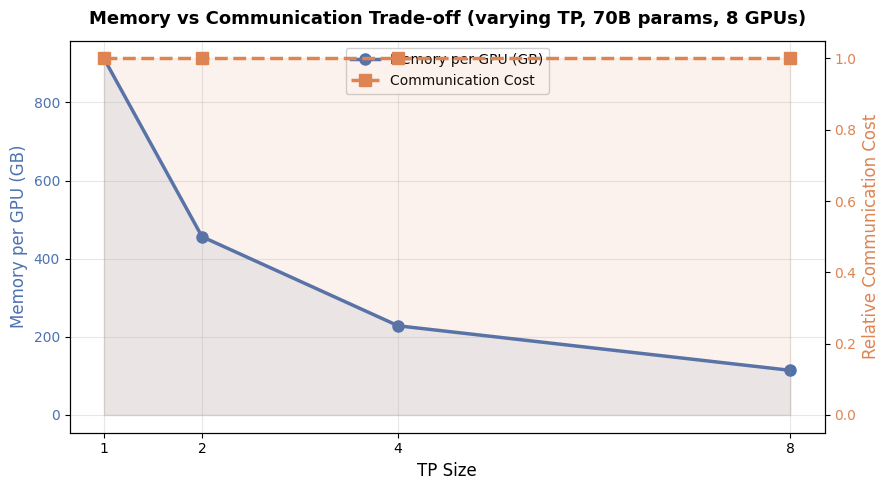

In [7]:
# Memory vs Communication trade-off: what happens as we increase TP?
fig, ax = draw_memory_comm_tradeoff(
    vary="tp", vary_range=[1, 2, 4, 8],
    pp_size=1, total_gpus=8, model_params=70e9
)
plt.show()

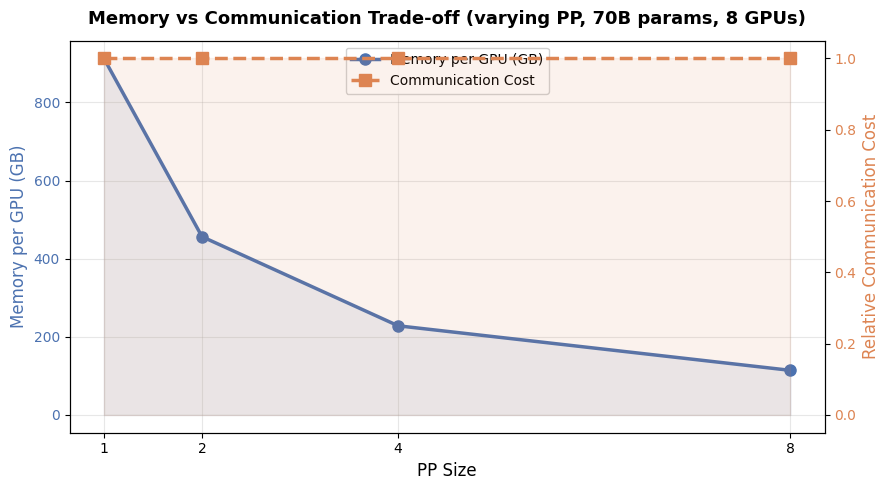

In [8]:
# Same trade-off, varying PP instead
fig, ax = draw_memory_comm_tradeoff(
    vary="pp", vary_range=[1, 2, 4, 8],
    tp_size=1, total_gpus=8, model_params=70e9
)
plt.show()

**Key takeaways from the trade-off plots:**
- Increasing TP **reduces memory** per GPU but **increases communication** (AllReduce every layer)
- Increasing PP **reduces memory** per GPU but **adds pipeline bubbles** (idle time)
- Pure DP has **lowest communication** but **highest memory** per GPU
- The sweet spot depends on your hardware: fast NVLink favors TP, many nodes favor PP+DP

## 4. Application in Large Language Models

### Real-World Configurations

Here are parallelism configurations used for well-known models:

| Model | Params | GPUs | TP | PP | DP | SP | EP | Notes |
|-------|--------|------|----|----|----|----|----|---------|
| **GPT-3** | 175B | 1024 A100 | 8 | 8 | 16 | — | — | 3D parallelism, classic Megatron |
| **LLaMA 65B** | 65B | 2048 A100 | 8 | 4 | 64 | ✓ | — | SP enabled for activation savings |
| **LLaMA 70B** | 70B | 2048 A100 | 8 | 4 | 64 | ✓ | — | GQA reduces TP comm overhead |
| **Mixtral 8×22B** | 141B | 512 H100 | 8 | 4 | 4 | ✓ | 4 | 5D parallelism with MoE |
| **Megatron-Turing NLG** | 530B | 2240 A100 | 8 | 35 | 8 | — | — | Extreme PP for huge model |

#### Patterns to Notice

1. **TP = 8** is almost universal — matches the 8 GPUs per DGX node connected via NVLink
2. **PP scales with model depth** — deeper models need more pipeline stages
3. **DP fills the remaining GPUs** — maximize throughput after TP+PP are set
4. **SP is always paired with TP** — free activation memory savings, no extra cost
5. **EP only for MoE models** — partitions expert replicas across the DP dimension

In [9]:
# Let's compute the memory breakdown for GPT-3 175B configuration
def compute_memory_breakdown(params_B, tp, pp, dp, hidden=12288, layers=96,
                              seq_len=2048, micro_batch=1, precision_bytes=2):
    """Compute approximate memory per GPU for a given parallelism config.
    
    Args:
        params_B: Total parameters in billions.
        tp, pp, dp: Parallelism sizes.
        hidden: Hidden dimension.
        layers: Total transformer layers.
        seq_len: Sequence length.
        micro_batch: Micro-batch size per GPU.
        precision_bytes: Bytes per parameter (2 for fp16).
    
    Returns:
        Dict with memory breakdown in GB.
    """
    P = params_B * 1e9
    params_per_gpu = P / (tp * pp)
    
    # Model weights (fp16)
    weight_mem = precision_bytes * params_per_gpu
    
    # Optimizer states (Adam: fp32 copy + momentum + variance = 12 bytes/param)
    optimizer_mem = 12 * params_per_gpu
    
    # Gradients (fp16)
    gradient_mem = precision_bytes * params_per_gpu
    
    # Activations (rough estimate: 2 * seq_len * hidden * layers/pp * micro_batch * 2 bytes)
    layers_per_stage = layers // pp
    activation_mem = 2 * seq_len * (hidden // tp) * layers_per_stage * micro_batch * precision_bytes
    
    to_gb = 1 / (1024**3)
    breakdown = {
        "Weights (fp16)": weight_mem * to_gb,
        "Optimizer (fp32)": optimizer_mem * to_gb,
        "Gradients (fp16)": gradient_mem * to_gb,
        "Activations": activation_mem * to_gb,
    }
    breakdown["Total"] = sum(breakdown.values())
    return breakdown

# GPT-3 175B: TP=8, PP=8, DP=16 on 1024 GPUs
mem = compute_memory_breakdown(175, tp=8, pp=8, dp=16, hidden=12288, layers=96)
print("GPT-3 175B — Memory per GPU (TP=8, PP=8, DP=16):")
print(f"{'Component':<25} {'GB':>8}")
print("-" * 35)
for k, v in mem.items():
    print(f"{k:<25} {v:>8.1f}")
print(f"\n→ Fits in 80GB A100? {'Yes ✓' if mem['Total'] < 80 else 'No ✗'}")

GPT-3 175B — Memory per GPU (TP=8, PP=8, DP=16):
Component                       GB
-----------------------------------
Weights (fp16)                 5.1
Optimizer (fp32)              30.6
Gradients (fp16)               5.1
Activations                    0.1
Total                         40.9

→ Fits in 80GB A100? Yes ✓


In [10]:
# Compare: what if we used different configs for the same 175B model?
configs_175b = [
    ("TP=8, PP=8", 8, 8),
    ("TP=8, PP=4", 8, 4),
    ("TP=4, PP=4", 4, 4),
    ("TP=8, PP=1", 8, 1),
]

print(f"{'Config':<20} {'Mem/GPU (GB)':>15} {'Fits 80GB?':>12}")
print("-" * 50)
for label, tp, pp in configs_175b:
    dp = max(1, 1024 // (tp * pp))
    mem = compute_memory_breakdown(175, tp=tp, pp=pp, dp=dp, hidden=12288, layers=96)
    fits = "Yes ✓" if mem['Total'] < 80 else "No ✗"
    print(f"{label:<20} {mem['Total']:>15.1f} {fits:>12}")

Config                  Mem/GPU (GB)   Fits 80GB?
--------------------------------------------------
TP=8, PP=8                      40.9        Yes ✓
TP=8, PP=4                      81.8         No ✗
TP=4, PP=4                     163.5         No ✗
TP=8, PP=1                     327.1         No ✗


Let's **visualize** that same comparison as a stacked bar chart — much easier to see
which components dominate and which configs actually fit in GPU memory:

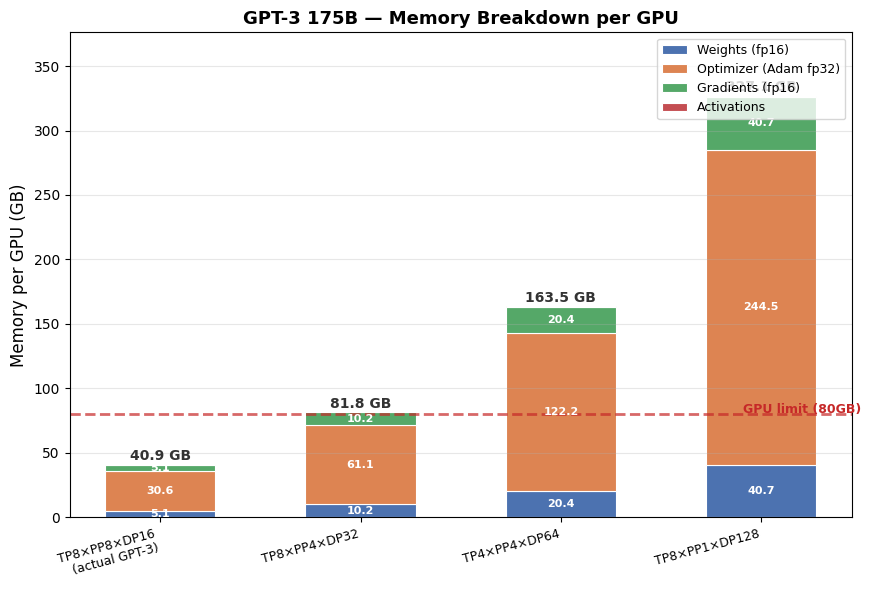

In [11]:
# Stacked memory breakdown: GPT-3 175B with different parallelism configs
configs_viz = [
    {"tp": 8, "pp": 8, "dp": 16, "label": "TP8×PP8×DP16\n(actual GPT-3)"},
    {"tp": 8, "pp": 4, "dp": 32, "label": "TP8×PP4×DP32"},
    {"tp": 4, "pp": 4, "dp": 64, "label": "TP4×PP4×DP64"},
    {"tp": 8, "pp": 1, "dp": 128, "label": "TP8×PP1×DP128"},
]

fig, ax = draw_memory_breakdown_chart(
    configs_viz, model_params_B=175, hidden=12288, layers=96,
    gpu_memory_gb=80,
    title="GPT-3 175B — Memory Breakdown per GPU"
)
plt.show()

## 5. Hands-On: Decision Framework

### The Parallelism Mix Decision Flowchart

Use this step-by-step process to decide your parallelism configuration.
The flowchart below guides you from "START" to a recommended mix:

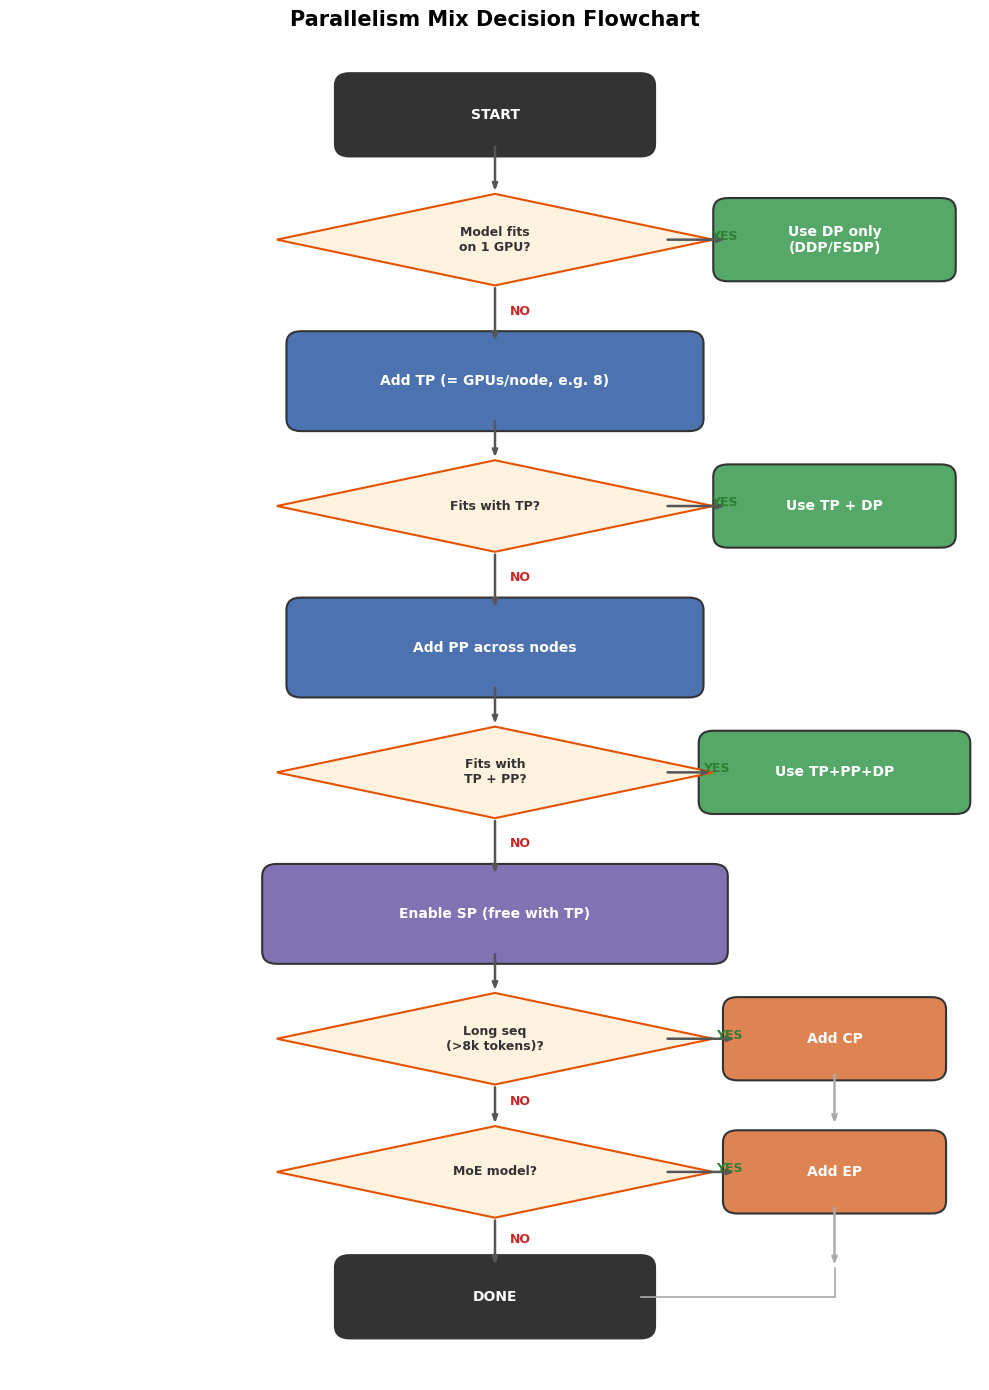

In [12]:
# Visual decision flowchart
fig, ax = draw_decision_flowchart()
plt.show()

In [13]:
def recommend_parallelism(model_params_B, num_gpus, gpu_memory_gb=80,
                           gpus_per_node=8, seq_len=2048, is_moe=False, num_experts=0):
    """Recommend a parallelism configuration based on model and cluster specs.
    
    Args:
        model_params_B: Total parameters in billions.
        num_gpus: Total available GPUs.
        gpu_memory_gb: Memory per GPU in GB.
        gpus_per_node: GPUs per node.
        seq_len: Training sequence length.
        is_moe: Whether this is a MoE model.
        num_experts: Number of experts (if MoE).
    
    Returns:
        Dict with recommended config and reasoning.
    """
    P = model_params_B * 1e9
    # Memory needed for model + optimizer (14 bytes/param for fp16 + Adam)
    model_memory_gb = (14 * P) / (1024**3)
    
    reasoning = []
    tp, pp, dp, sp, cp, ep = 1, 1, num_gpus, False, 1, 1
    
    # Step 1: Does it fit on 1 GPU?
    if model_memory_gb <= gpu_memory_gb * 0.8:  # 80% headroom for activations
        reasoning.append(f"Model ({model_memory_gb:.1f}GB) fits on 1 GPU → Pure DP")
        return {"tp": 1, "pp": 1, "dp": num_gpus, "sp": False, "cp": 1, "ep": 1,
                "reasoning": reasoning}
    
    # Step 2: Add TP (within node)
    tp = min(gpus_per_node, num_gpus)
    mem_with_tp = model_memory_gb / tp
    reasoning.append(f"Model too large ({model_memory_gb:.1f}GB) → Add TP={tp}")
    reasoning.append(f"  Memory per GPU with TP: {mem_with_tp:.1f}GB")
    
    if mem_with_tp <= gpu_memory_gb * 0.8:
        dp = num_gpus // tp
        reasoning.append(f"Fits with TP={tp} → TP + DP (DP={dp})")
        return {"tp": tp, "pp": 1, "dp": dp, "sp": True, "cp": 1, "ep": 1,
                "reasoning": reasoning}
    
    # Step 3: Add PP
    pp = 1
    while model_memory_gb / (tp * pp) > gpu_memory_gb * 0.7:
        pp *= 2
        if tp * pp > num_gpus:
            break
    dp = num_gpus // (tp * pp)
    sp = True  # Always enable SP when TP > 1
    mem_final = model_memory_gb / (tp * pp)
    reasoning.append(f"Still too large → Add PP={pp}")
    reasoning.append(f"  Memory per GPU: {mem_final:.1f}GB")
    reasoning.append(f"  Final: TP={tp}, PP={pp}, DP={dp}, SP={sp}")
    
    # Step 4: Long sequences → CP
    if seq_len > 8192 and dp > 1:
        cp = min(4, dp)
        dp = dp // cp
        reasoning.append(f"Long seq ({seq_len}) → Add CP={cp}, DP reduced to {dp}")
    
    # Step 5: MoE → EP
    if is_moe and num_experts > 1 and dp > 1:
        ep = min(num_experts, dp)
        dp = dp // ep
        reasoning.append(f"MoE ({num_experts} experts) → Add EP={ep}, DP reduced to {dp}")
    
    return {"tp": tp, "pp": pp, "dp": dp, "sp": sp, "cp": cp, "ep": ep,
            "reasoning": reasoning}

In [14]:
# Example 1: LLaMA 7B on 8 GPUs
result = recommend_parallelism(7, num_gpus=8, gpu_memory_gb=80)
print("=" * 50)
print("LLaMA 7B on 8× A100-80GB")
print("=" * 50)
for line in result["reasoning"]:
    print(f"  {line}")
print(f"\n  → Config: TP={result['tp']}, PP={result['pp']}, DP={result['dp']}")

LLaMA 7B on 8× A100-80GB
  Model too large (91.3GB) → Add TP=8
    Memory per GPU with TP: 11.4GB
  Fits with TP=8 → TP + DP (DP=1)

  → Config: TP=8, PP=1, DP=1


In [15]:
# Example 2: LLaMA 70B on 64 GPUs
result = recommend_parallelism(70, num_gpus=64, gpu_memory_gb=80)
print("=" * 50)
print("LLaMA 70B on 64× A100-80GB")
print("=" * 50)
for line in result["reasoning"]:
    print(f"  {line}")
print(f"\n  → Config: TP={result['tp']}, PP={result['pp']}, DP={result['dp']}, SP={result['sp']}")

LLaMA 70B on 64× A100-80GB
  Model too large (912.7GB) → Add TP=8
    Memory per GPU with TP: 114.1GB
  Still too large → Add PP=4
    Memory per GPU: 28.5GB
    Final: TP=8, PP=4, DP=2, SP=True

  → Config: TP=8, PP=4, DP=2, SP=True


In [16]:
# Example 3: GPT-3 175B on 1024 GPUs
result = recommend_parallelism(175, num_gpus=1024, gpu_memory_gb=80)
print("=" * 50)
print("GPT-3 175B on 1024× A100-80GB")
print("=" * 50)
for line in result["reasoning"]:
    print(f"  {line}")
print(f"\n  → Config: TP={result['tp']}, PP={result['pp']}, DP={result['dp']}, SP={result['sp']}")

GPT-3 175B on 1024× A100-80GB
  Model too large (2281.7GB) → Add TP=8
    Memory per GPU with TP: 285.2GB
  Still too large → Add PP=8
    Memory per GPU: 35.7GB
    Final: TP=8, PP=8, DP=16, SP=True

  → Config: TP=8, PP=8, DP=16, SP=True


In [17]:
# Example 4: Mixtral 8×22B (MoE) on 512 GPUs with long sequences
result = recommend_parallelism(141, num_gpus=512, gpu_memory_gb=80,
                                seq_len=32768, is_moe=True, num_experts=8)
print("=" * 50)
print("Mixtral 8×22B on 512× H100-80GB (seq=32k)")
print("=" * 50)
for line in result["reasoning"]:
    print(f"  {line}")
print(f"\n  → Config: TP={result['tp']}, PP={result['pp']}, DP={result['dp']}, "
      f"SP={result['sp']}, CP={result['cp']}, EP={result['ep']}")

Mixtral 8×22B on 512× H100-80GB (seq=32k)
  Model too large (1838.4GB) → Add TP=8
    Memory per GPU with TP: 229.8GB
  Still too large → Add PP=8
    Memory per GPU: 28.7GB
    Final: TP=8, PP=8, DP=8, SP=True
  Long seq (32768) → Add CP=4, DP reduced to 2
  MoE (8 experts) → Add EP=2, DP reduced to 1

  → Config: TP=8, PP=8, DP=1, SP=True, CP=4, EP=2


### Interactive Memory Calculator

Try your own configurations! Modify the parameters below to see how memory and
communication change.

In [18]:
# === MODIFY THESE PARAMETERS ===
MODEL_PARAMS_B = 70      # Model size in billions
TOTAL_GPUS     = 64      # Total GPUs in your cluster
GPU_MEMORY_GB  = 80      # Memory per GPU (e.g., 40, 80)
GPUS_PER_NODE  = 8       # GPUs per node

# Try different configs
my_configs = [
    {"tp": 1, "pp": 1, "dp": 64},   # Pure DP
    {"tp": 8, "pp": 1, "dp": 8},    # TP only
    {"tp": 8, "pp": 2, "dp": 4},    # TP + PP
    {"tp": 8, "pp": 4, "dp": 2},    # More PP
]

print(f"Model: {MODEL_PARAMS_B}B params | Cluster: {TOTAL_GPUS} GPUs | GPU: {GPU_MEMORY_GB}GB")
print("=" * 70)
print(f"{'Config':<20} {'Mem/GPU':>10} {'Fits?':>8} {'DP throughput':>15}")
print("-" * 70)

for cfg in my_configs:
    tp, pp, dp = cfg['tp'], cfg['pp'], cfg['dp']
    if tp * pp * dp != TOTAL_GPUS:
        print(f"TP{tp}×PP{pp}×DP{dp}  — INVALID (product ≠ {TOTAL_GPUS})")
        continue
    mem = compute_memory_breakdown(MODEL_PARAMS_B, tp=tp, pp=pp, dp=dp)
    fits = "Yes ✓" if mem['Total'] < GPU_MEMORY_GB else "No ✗"
    # DP throughput: higher DP = more data parallelism = higher throughput
    # But PP adds bubble overhead: efficiency ≈ M/(M+P-1) where M=microbatches, P=stages
    bubble_eff = 1.0 if pp == 1 else 8 / (8 + pp - 1)  # assume 8 microbatches
    throughput = f"DP={dp}, eff={bubble_eff:.0%}"
    label = f"TP{tp}×PP{pp}×DP{dp}"
    print(f"{label:<20} {mem['Total']:>8.1f}GB {fits:>8} {throughput:>15}")

Model: 70B params | Cluster: 64 GPUs | GPU: 80GB
Config                  Mem/GPU    Fits?   DP throughput
----------------------------------------------------------------------
TP1×PP1×DP64           1052.1GB     No ✗ DP=64, eff=100%
TP8×PP1×DP8             131.5GB     No ✗  DP=8, eff=100%
TP8×PP2×DP4              65.8GB    Yes ✓   DP=4, eff=89%
TP8×PP4×DP2              32.9GB    Yes ✓   DP=2, eff=73%


## 6. Megatron-LM Reference

Megatron-LM uses command-line flags to configure the parallelism mix. Here are the key flags:

| Flag | Default | Description |
|------|---------|-------------|
| `--tensor-model-parallel-size` | 1 | TP degree — splits weight matrices across GPUs within a node |
| `--pipeline-model-parallel-size` | 1 | PP degree — splits model layers into pipeline stages |
| `--data-parallel-size` | auto | DP degree — auto-calculated as total_gpus / (TP × PP) |
| `--sequence-parallel` | off | Enables SP — partitions activations along sequence dim (requires TP > 1) |
| `--context-parallel-size` | 1 | CP degree — splits long sequences across GPUs with ring attention |
| `--num-experts` | — | Number of MoE experts per layer |
| `--expert-model-parallel-size` | 1 | EP degree — distributes experts across GPUs |
| `--num-layers-per-virtual-pipeline-stage` | — | Interleaved PP — reduces bubble by assigning multiple non-contiguous chunks per GPU |
| `--micro-batch-size` | — | Micro-batch per GPU — smaller = less activation memory, more pipeline bubbles |
| `--global-batch-size` | — | Total batch = micro × DP × gradient_acc_steps |

In [19]:
# Example Megatron-LM launch commands for different scales

megatron_examples = {
    "GPT-3 175B (1024 GPUs)": """
torchrun --nproc_per_node=8 --nnodes=128 \\
    pretrain_gpt.py \\
    --tensor-model-parallel-size 8 \\
    --pipeline-model-parallel-size 8 \\
    --micro-batch-size 1 \\
    --global-batch-size 1536 \\
    --sequence-parallel \\
    --num-layers 96 \\
    --hidden-size 12288 \\
    --num-attention-heads 96
""",
    "LLaMA 70B (64 GPUs)": """
torchrun --nproc_per_node=8 --nnodes=8 \\
    pretrain_gpt.py \\
    --tensor-model-parallel-size 8 \\
    --pipeline-model-parallel-size 2 \\
    --micro-batch-size 1 \\
    --global-batch-size 256 \\
    --sequence-parallel \\
    --num-layers 80 \\
    --hidden-size 8192 \\
    --num-attention-heads 64
""",
    "Mixtral 8×22B MoE (512 GPUs)": """
torchrun --nproc_per_node=8 --nnodes=64 \\
    pretrain_gpt.py \\
    --tensor-model-parallel-size 8 \\
    --pipeline-model-parallel-size 4 \\
    --expert-model-parallel-size 4 \\
    --num-experts 8 \\
    --micro-batch-size 1 \\
    --global-batch-size 128 \\
    --sequence-parallel \\
    --context-parallel-size 2 \\
    --seq-length 32768
""",
}

for name, cmd in megatron_examples.items():
    print(f"# {name}")
    print(cmd)

# GPT-3 175B (1024 GPUs)

torchrun --nproc_per_node=8 --nnodes=128 \
    pretrain_gpt.py \
    --tensor-model-parallel-size 8 \
    --pipeline-model-parallel-size 8 \
    --micro-batch-size 1 \
    --global-batch-size 1536 \
    --sequence-parallel \
    --num-layers 96 \
    --hidden-size 12288 \
    --num-attention-heads 96

# LLaMA 70B (64 GPUs)

torchrun --nproc_per_node=8 --nnodes=8 \
    pretrain_gpt.py \
    --tensor-model-parallel-size 8 \
    --pipeline-model-parallel-size 2 \
    --micro-batch-size 1 \
    --global-batch-size 256 \
    --sequence-parallel \
    --num-layers 80 \
    --hidden-size 8192 \
    --num-attention-heads 64

# Mixtral 8×22B MoE (512 GPUs)

torchrun --nproc_per_node=8 --nnodes=64 \
    pretrain_gpt.py \
    --tensor-model-parallel-size 8 \
    --pipeline-model-parallel-size 4 \
    --expert-model-parallel-size 4 \
    --num-experts 8 \
    --micro-batch-size 1 \
    --global-batch-size 128 \
    --sequence-parallel \
    --context-parallel-size 2 \
   

## 7. Summary & Further Reading

### Key Takeaways

1. **Parallelism dimensions are mostly orthogonal**: DP × TP × PP compose freely. SP piggybacks on TP. EP subdivides DP.

2. **Place TP innermost** (within node, on NVLink) because it communicates every layer. PP and DP can use slower cross-node links.

3. **Start simple, add dimensions as needed**: DP only → add TP when model doesn't fit → add PP for very large models → SP is free → CP for long sequences → EP for MoE.

4. **Memory decreases as**: $M \propto \frac{P}{TP \times PP}$, but communication increases with each added dimension.

5. **Pipeline bubbles** are the main cost of PP: efficiency ≈ $\frac{M}{M + P - 1}$ where M = micro-batches, P = pipeline stages.

### Key Formulas

| Formula | Meaning |
|---------|----------|
| $\text{Total GPUs} = DP \times TP \times PP$ | Basic GPU count equation |
| $M_{\text{params/GPU}} = \frac{2P}{TP \times PP}$ | fp16 model memory per GPU |
| $M_{\text{optim/GPU}} = \frac{12P}{TP \times PP}$ | Adam optimizer memory per GPU |
| $\eta_{\text{pipeline}} = \frac{M}{M + P - 1}$ | Pipeline efficiency (M=microbatches, P=stages) |

### Further Reading

- [Megatron-LM Paper: Efficient Large-Scale Language Model Training on GPU Clusters](https://arxiv.org/abs/2104.04473)
- [Reducing Activation Recomputation in Large Transformer Models (SP)](https://arxiv.org/abs/2205.05198)
- [Ring Attention with Blockwise Transformers (CP)](https://arxiv.org/abs/2310.01889)
- [Switch Transformers (MoE/EP)](https://arxiv.org/abs/2101.03961)
- [DeepSpeed ZeRO](https://arxiv.org/abs/1910.02054)

### Next Steps

You've now covered all the parallelism dimensions and how to combine them!
Check out `notebooks/07-advanced-topics/` for more specialized topics like
activation checkpointing, gradient accumulation, and mixed-precision training details.